<a href="https://colab.research.google.com/github/SteveChengChen/data-analysis/blob/main/STAT_5293_final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, truncnorm, invgamma
import seaborn as sns
sns.set_style("whitegrid")

np.random.seed(42)

NUM_SIMULATIONS = 1000
N_EXPERIMENTS    = 30
ALPHA            = 0.05
Z_CUTOFF         = norm.ppf(1 - ALPHA)
B_BOOTSTRAP      = 1000

In [5]:
def sample_a_i_trunc_normal(n):

    lower, upper = -1.5, 2.0
    mu, sigma = 0.2, 0.7
    a_ = (lower - mu) / sigma
    b_ = (upper - mu) / sigma
    return truncnorm.rvs(a_, b_, loc=mu, scale=sigma, size=n)

def sample_sigma_i_invgamma(n):

    shape_param, scale_param = 3.0, 1.0
    sigma_sq = invgamma.rvs(a=shape_param, scale=scale_param, size=n)
    return np.sqrt(sigma_sq)

def bias_corrected_estimate(X, sigma, alpha=ALPHA):

    b = norm.ppf(1 - alpha)
    sel = (X / sigma) > b
    S_A = X[sel].sum()

    beta_sum = 0.0
    for i in range(len(X)):
        z_i = b * sigma[i] - X[i]
        p_i = 1 - norm.cdf(b - (X[i]/sigma[i]))
        if p_i < 1e-15:
            continue
        ratio = (1.0 / sigma[i]) * norm.pdf(b - (X[i]/sigma[i])) / p_i
        beta_sum += sigma[i] * ratio

    T_hat_A = S_A - beta_sum
    return S_A, T_hat_A, sel

def conditional_debiased_estimate(X, sigma, sel_mask, alpha=ALPHA):

    b = norm.ppf(1 - alpha)
    sum_cond = 0.0
    selected_indices = np.where(sel_mask)[0]
    for i in selected_indices:
        p_i = 1 - norm.cdf(b - (X[i] / sigma[i]))
        if p_i < 1e-15:
            continue
        ratio = (1.0 / sigma[i]) * norm.pdf(b - (X[i] / sigma[i])) / p_i
        sum_cond += X[i] - sigma[i] * ratio
    return sum_cond

def run_one_simulation(n=30, alpha=ALPHA):

    a_i = sample_a_i_trunc_normal(n)
    s_i = sample_sigma_i_invgamma(n)
    X_i = np.random.normal(a_i, s_i, size=n)

    b_cut = norm.ppf(1 - alpha)
    sel = (X_i / s_i) > b_cut

    T_A = a_i[sel].sum()
    S_A = X_i[sel].sum()

    S_A_temp, T_hat_A, sel_mask = bias_corrected_estimate(X_i, s_i, alpha)

    T_hat_A_cond = conditional_debiased_estimate(X_i, s_i, sel_mask, alpha)

    return {
        'num_selected': sel.sum(),
        'S_A': S_A,
        'T_A': T_A,
        'T_hat_A': T_hat_A,
        'T_hat_A_cond': T_hat_A_cond,
        'beta': S_A - T_A
    }

In [12]:
all_sims = []
for _ in range(NUM_SIMULATIONS):
    all_sims.append(run_one_simulation(N_EXPERIMENTS, ALPHA))
df = pd.DataFrame(all_sims)

desc_cols = ['num_selected','S_A','T_hat_A_cond','T_hat_A','T_A','beta']
desc_stats = df[desc_cols].describe(percentiles=[0.25,0.5,0.75])
table1 = desc_stats.loc[['min','25%','50%','mean','75%','max']]
print("\nTABLE 1: Summary of 1000 Simulations\n")
print(table1)


TABLE 1: Summary of 1000 Simulations

      num_selected        S_A  T_hat_A_cond    T_hat_A        T_A       beta
min          0.000   0.000000      0.000000 -77.958741  -0.078478  -1.163784
25%          4.000   6.207306      4.202200 -54.663637   3.556230   1.869864
50%          6.000   8.241415      5.948141 -48.811577   5.007836   3.098348
mean         5.729   8.452799      6.105900 -48.916754   5.148413   3.304386
75%          7.000  10.666318      7.872831 -42.881515   6.590867   4.499338
max         14.000  20.566778     17.030767 -23.006521  14.243046  10.013713


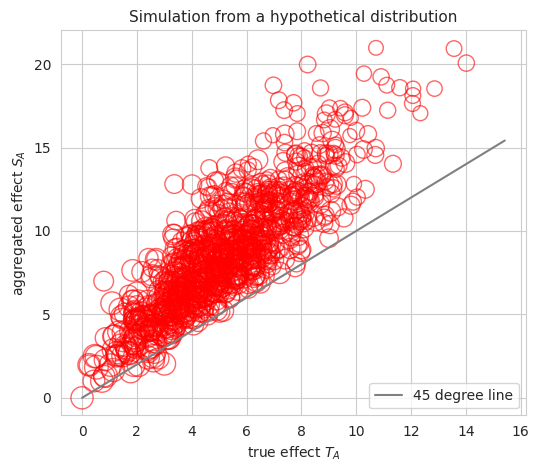

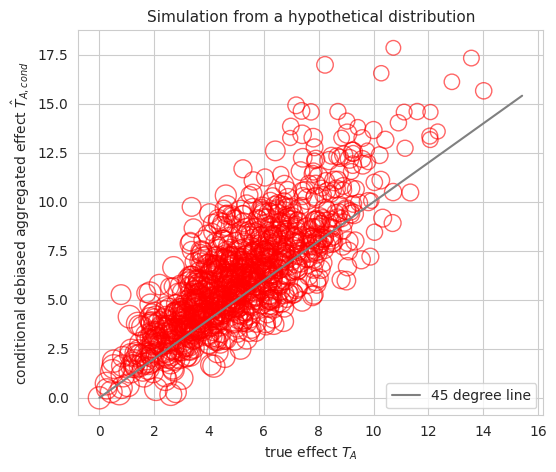

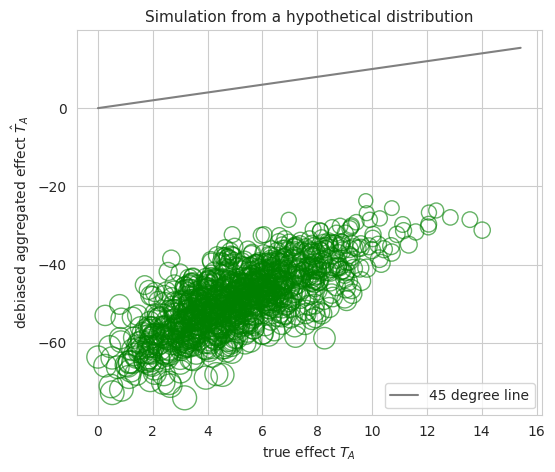

In [10]:
def plot_figures(df):

    xvals = df['T_A'].values
    yvals = df['T_hat_A'].values
    dist = np.sqrt(xvals**2 + yvals**2)
    marker_size = 4*dist
    # Figure 3
    plt.figure(figsize=(6,5))
    plt.scatter(df['T_A'], df['S_A'], color='red',facecolors='none', alpha=0.6, s=marker_size)
    plt.title("Simulation from a hypothetical distribution", fontsize=11)
    plt.xlabel("true effect $T_A$")
    plt.ylabel("aggregated effect $S_A$")

    x_vals = np.linspace(0, max(df['T_A'].max(),0)*1.1, 200)
    plt.plot(x_vals, x_vals, color='gray', label="45 degree line")
    plt.legend(loc="lower right")
    plt.show()

    # Figure 4
    plt.figure(figsize=(6,5))
    plt.scatter(df['T_A'], df['T_hat_A_cond'], color='red',facecolors='none', alpha=0.6, s=marker_size)
    plt.title("Simulation from a hypothetical distribution", fontsize=11)
    plt.xlabel("true effect $T_A$")
    plt.ylabel("conditional debiased aggregated effect $\hat{T}_{A,cond}$")
    x_vals = np.linspace(0, max(df['T_A'].max(),0)*1.1, 200)
    plt.plot(x_vals, x_vals, color='gray', label="45 degree line")
    plt.legend(loc="lower right")
    plt.show()

    # Figure 5
    plt.figure(figsize=(6,5))
    plt.scatter(df['T_A'], df['T_hat_A'], color='green',facecolors='none', alpha=0.6, s=marker_size)
    plt.title("Simulation from a hypothetical distribution", fontsize=11)
    plt.xlabel("true effect $T_A$")
    plt.ylabel("debiased aggregated effect $\hat{T}_A$")
    x_vals = np.linspace(0, max(df['T_A'].max(),0)*1.1, 200)
    plt.plot(x_vals, x_vals, color='gray', label="45 degree line")
    plt.legend(loc="lower right")
    plt.show()

plot_figures(df)

In [13]:
def coverage_study(n_sims=1000, n=30, alpha=0.05, B=1000,
                   coverage_levels=[0.7,0.8,0.9,0.95]):

    coverage_counts = {
        'Naive':    {c:0 for c in coverage_levels},
        'Bootstrap':{c:0 for c in coverage_levels},
        'Debiased': {c:0 for c in coverage_levels},
    }

    b_cut = norm.ppf(1 - alpha)

    for _sim in range(n_sims):

        a_i = sample_a_i_trunc_normal(n)
        s_i = sample_sigma_i_invgamma(n)
        X_i = np.random.normal(a_i, s_i, size=n)

        sel = (X_i / s_i) > b_cut
        if not np.any(sel):

            continue

        T_A = a_i[sel].sum()
        S_A_obs = X_i[sel].sum()
        s_sel = s_i[sel]

        SA_b_list = []
        Tdeb_b_list = []
        for _b in range(B):
            Xb = np.random.normal(X_i, s_i, size=n)

            Sb = Xb[sel].sum()
            SA_b_list.append(Sb)

            beta_sum = 0.0
            for i_idx in np.where(sel)[0]:
                p_i = 1 - norm.cdf(b_cut - (Xb[i_idx]/s_i[i_idx]))
                if p_i < 1e-15:
                    continue
                ratio = (1.0 / s_i[i_idx]) * norm.pdf(b_cut - (Xb[i_idx]/s_i[i_idx])) / p_i
                beta_sum += s_i[i_idx] * ratio
            Tdeb_b_list.append(Sb - beta_sum)

        SA_b_list = np.array(SA_b_list)
        Tdeb_b_list = np.array(Tdeb_b_list)

        for c in coverage_levels:

            lower_pct = (1 - c)/2 * 100
            upper_pct = (1 - (1 - c)/2)*100
            z_val = norm.ppf(0.5 + c/2)

            total_se = s_sel.sum()
            naive_low = S_A_obs - z_val * total_se
            naive_high = S_A_obs + z_val * total_se
            if naive_low <= T_A <= naive_high:
                coverage_counts['Naive'][c] += 1

            lb_s = np.percentile(SA_b_list, lower_pct)
            ub_s = np.percentile(SA_b_list, upper_pct)
            if lb_s <= T_A <= ub_s:
                coverage_counts['Bootstrap'][c] += 1

            lb_d = np.percentile(Tdeb_b_list, lower_pct)
            ub_d = np.percentile(Tdeb_b_list, upper_pct)
            if lb_d <= T_A <= ub_d:
                coverage_counts['Debiased'][c] += 1

    rows = []
    for c in coverage_levels:
        rows.append({
            'Target Coverage': c,
            'Naive': coverage_counts['Naive'][c] / n_sims,
            'Bootstrap': coverage_counts['Bootstrap'][c] / n_sims,
            'Debiased': coverage_counts['Debiased'][c] / n_sims
        })
    return pd.DataFrame(rows)

table2_df = coverage_study(
    n_sims=NUM_SIMULATIONS,
    n=N_EXPERIMENTS,
    alpha=ALPHA,
    B=B_BOOTSTRAP,
    coverage_levels=[0.7, 0.8, 0.9, 0.95]
)

print("\nTABLE 2: Coverage of the 95 % confidence intervals\n")
print(table2_df.to_string(index=False, float_format='%.3f'))


TABLE 2: Coverage of the 95 % confidence intervals

 Target Coverage  Naive  Bootstrap  Debiased
           0.700  0.579      0.123     0.876
           0.800  0.796      0.164     0.941
           0.900  0.964      0.277     0.984
           0.950  0.989      0.397     0.994
